<a href="https://colab.research.google.com/github/JacobeJonathan/mareduce/blob/main/Caso_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Caso 1:

Dado un dataset que contenga entradas con la forma “persona;producto;cantidad;esDevolucion”, crea un programa llamado dineroGastadoPorClientes que indique para cada cliente cuánto dinero gastó en total. Se valorará positivamente la optimización del programa, por ejemplo, a través de la funcionalidad Combiner. Se proporciona el archivo de datos dataset_bigdata_10000.csv. Ejemplo:

Persona,Producto,Cantidad,Devolucion

Alice;Camiseta;10;Falso

Alice;Camiseta;10;Cierto

Alice;Pantalones;20;Falso

Bob;Camiseta;5;Falso

Bob;Camiseta;7;Falso



crea un programa llamado dineroGastadoPorClientes que indique para cada cliente cuánto dinero gastó en total

In [ ]:
import csv
from collections import defaultdict
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [ ]:
# Ruta del archivo subido en Colab
file_path = "/content/dataset_bigdata_10000.csv"

# Leer archivo y cargar datos (ignorando la cabecera si existe)
data = []
with open(file_path, "r", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    primera_linea = next(reader)  # Leer primera línea
    # Comprobar si es cabecera o dato real
    if primera_linea[0].strip().lower() not in ("persona", "cliente", "nombre"):
        # No era cabecera, procesarla como dato
        persona = primera_linea[0].strip()
        cantidad = float(primera_linea[2].strip())
        es_dev = primera_linea[3].strip().lower()
        data.append([persona, primera_linea[1].strip(), cantidad, es_dev])
    for row in reader:
        if len(row) != 4:
            continue
        persona = row[0].strip()
        producto = row[1].strip()
        try:
            cantidad = float(row[2].strip())
        except ValueError:
            continue
        es_dev = row[3].strip().lower()
        data.append([persona, producto, cantidad, es_dev])

print(f"Archivo cargado: {file_path}")
print(f"Número total de registros: {len(data)}")
print("Primeras 5 líneas de ejemplo:")
for row in data[:5]:
    print(row)

Archivo cargado: /content/dataset_bigdata_10000.csv
Número total de registros: 10000
Primeras 5 líneas de ejemplo:
['Alice', 'Pantalones', 21.0, 'falso']
['Bob', 'Bufanda', 15.0, 'falso']
['Diana', 'Bufanda', 24.0, 'falso']
['Eve', 'Zapatos', 5.0, 'cierto']
['Grace', 'Calcetines', 15.0, 'falso']


In [ ]:
N = 5  # número de nodos
chunk_size = len(data) // N
nodos = [data[i*chunk_size:(i+1)*chunk_size] for i in range(N-1)]
nodos.append(data[(N-1)*chunk_size:])

for i, nodo in enumerate(nodos):
    print(f"Nodo {i+1} tiene {len(nodo)} registros")

Nodo 1 tiene 2000 registros
Nodo 2 tiene 2000 registros
Nodo 3 tiene 2000 registros
Nodo 4 tiene 2000 registros
Nodo 5 tiene 2000 registros


In [ ]:
from collections import defaultdict

def combiner_nodo(mapped):
    parcial = defaultdict(int)
    for persona, cantidad in mapped:
        parcial[persona] += cantidad
    return parcial

FUNCION MAP

In [ ]:
def map_nodo(lines):
    mapped = []
    for persona, producto, cantidad, es_dev in lines:
        # Si es devolución, la cantidad es negativa
        if es_dev in ("cierto", "true", "sí", "si", "1"):
            cantidad = -cantidad
        mapped.append((persona, cantidad))
    return mapped

FUNCION COMBINER

In [ ]:
def combiner_nodo(mapped):
    parcial = defaultdict(float)
    for persona, cantidad in mapped:
        parcial[persona] += cantidad
    return parcial

MAP  COMBINER POR NODO

In [ ]:
resultados_nodos = []


for i, nodo in enumerate(nodos):
    print(f"\nProcesando Nodo {i+1}...")
    mapped = map_nodo(nodo)
    print(f"Pares MAP Nodo {i+1} (primeros 5): {mapped[:5]}")

    parcial = combiner_nodo(mapped)
    resultados_nodos.append(parcial)

    print(f"Resultados parciales Nodo {i+1} (primeros 5 clientes):")
    for persona, total in list(parcial.items())[:5]:
        print(f"  {persona} → Parcial: {total}")


Procesando Nodo 1...
Pares MAP Nodo 1 (primeros 5): [('Alice', 21.0), ('Bob', 15.0), ('Diana', 24.0), ('Eve', -5.0), ('Grace', 15.0)]
Resultados parciales Nodo 1 (primeros 5 clientes):
  Alice → Parcial: 3862.0
  Bob → Parcial: 4201.0
  Diana → Parcial: 4403.0
  Eve → Parcial: 3763.0
  Grace → Parcial: 3240.0

Procesando Nodo 2...
Pares MAP Nodo 2 (primeros 5): [('Alice', 25.0), ('Irene', 35.0), ('Frank', 10.0), ('Eve', -34.0), ('Jack', 29.0)]
Resultados parciales Nodo 2 (primeros 5 clientes):
  Alice → Parcial: 5312.0
  Irene → Parcial: 3876.0
  Frank → Parcial: 3578.0
  Eve → Parcial: 3101.0
  Jack → Parcial: 3951.0

Procesando Nodo 3...
Pares MAP Nodo 3 (primeros 5): [('Alice', 42.0), ('Frank', 36.0), ('Frank', 19.0), ('Hector', 20.0), ('Bob', 26.0)]
Resultados parciales Nodo 3 (primeros 5 clientes):
  Alice → Parcial: 3967.0
  Frank → Parcial: 3581.0
  Hector → Parcial: 4079.0
  Bob → Parcial: 3670.0
  Grace → Parcial: 5266.0

Procesando Nodo 4...
Pares MAP Nodo 4 (primeros 5): [(

REDUCER

In [ ]:
resultado_final = defaultdict(float)

for parcial in resultados_nodos:
    for persona, total in parcial.items():
        resultado_final[persona] += total

# Ordenar por nombre de cliente
resultado_final = dict(sorted(resultado_final.items()))

print("\nRESULTADO FINAL (primeros 10 clientes):")
for persona, total in list(resultado_final.items())[:10]:
    print(f"{persona} → {total}")


RESULTADO FINAL (primeros 10 clientes):
Alice → 21125.0
Bob → 18925.0
Charlie → 18995.0
Diana → 19550.0
Eve → 18608.0
Frank → 19781.0
Grace → 20358.0
Hector → 18829.0
Irene → 19152.0
Jack → 20371.0


TOP CLIENTES QUE MAS GASTARON

In [ ]:
top_clientes = sorted(resultado_final.items(), key=lambda x: x[1], reverse=True)

print("\nTOP 5 clientes que más gastaron:")
for persona, total in top_clientes[:5]:
    print(f"{persona} → Total gastado: {total}")


TOP 5 clientes que más gastaron:
Alice → Total gastado: 21125.0
Jack → Total gastado: 20371.0
Grace → Total gastado: 20358.0
Frank → Total gastado: 19781.0
Diana → Total gastado: 19550.0


GRAFICO

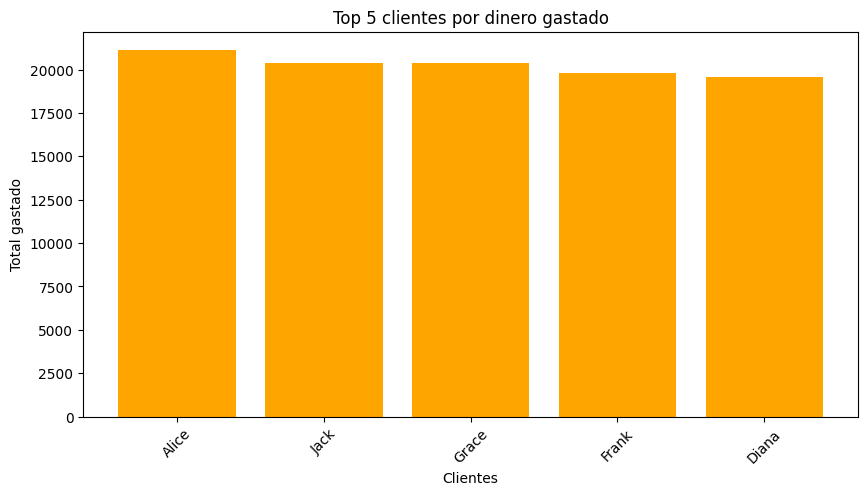

In [ ]:
nombres_top = [x[0] for x in top_clientes[:5]]
totales_top = [x[1] for x in top_clientes[:5]]

plt.figure(figsize=(10, 5))
plt.bar(nombres_top, totales_top, color="orange")
plt.xlabel("Clientes")
plt.ylabel("Total gastado")
plt.title("Top 5 clientes por dinero gastado")
plt.xticks(rotation=45)
plt.show()